In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
#discrete dynamic model (romeo and juliet)
def romeo_julia(R0, L0, aR, aL, pR, pL, T=100):
    # define arrays for T+1 iterations
    R = np.zeros(T+1)
    L = np.zeros(T+1)
   # initial conditions
    R[0], L[0] = R0, L0

    for n in range(T):
        # romeo's discrete equation, reacts to his previous feeling aR and juliet's feeling pR, juliet analogously
        R[n+1] = aR * R[n] + pR * L[n]
        L[n+1] = aL * L[n] + pL * R[n]

    return R, L


In [3]:
def plot_results(R, L, title):
    n = np.arange(len(R))

    plt.figure(figsize=(12,5))

    # plot of Rn i Ln overtime
    plt.subplot(1,2,1)
    plt.plot(n, R, label='Romeo', linewidth=2)
    plt.plot(n, L, label='Julia', linewidth=2, linestyle='--')
    plt.xlabel("TIme")
    plt.ylabel("Romeo i Julia")
    plt.title("Rₙ i Lₙ as functions of time ")
    plt.legend()
    plt.grid(True)

    # phase portrait
    plt.subplot(1,2,2)
    plt.plot(R, L, marker='o', markersize=3)
    plt.xlabel("Romeo")
    plt.ylabel("Julia")
    plt.title("Phase portrait")
    plt.grid(True)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

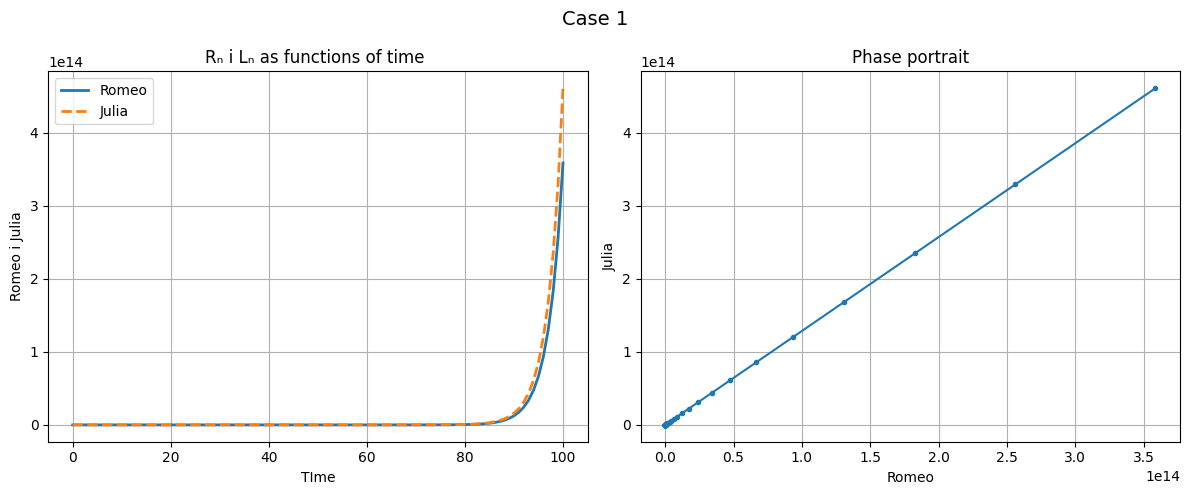

In [4]:
R, L = romeo_julia(R0=1, L0=1, aR=0.5, aL=0.7, pR=0.7, pL=0.9)
plot_results(R, L, "Case 1")

### Conclusion
In the first case, Romeo and Juliet begin with a moderate state of love (R0 = L0 = 1). The parameters aR and aL take values ​​less than 1, so if Romeo and Juliet were only reacting to the dynamics of their own feelings, their feelings toward each other would become neutral.

Positive feedback can lead to a strengthening of feelings, but only when the effect of mutual reaction exceeds the natural suppression of emotions (i.e., when the combination of a+p gives a value greater than 1). The stronger the parameters pR and pL, the faster love "explodes."

It can be verified that regardless of the choice of starting points, with such selected parameters aR, aL, pR, and pL, the result is always the same: as n → ∞, Rn, Ln → ∞.
We therefore conclude that from initial neutral feelings of love/hate, these feelings converge to a state of intense infatuation.

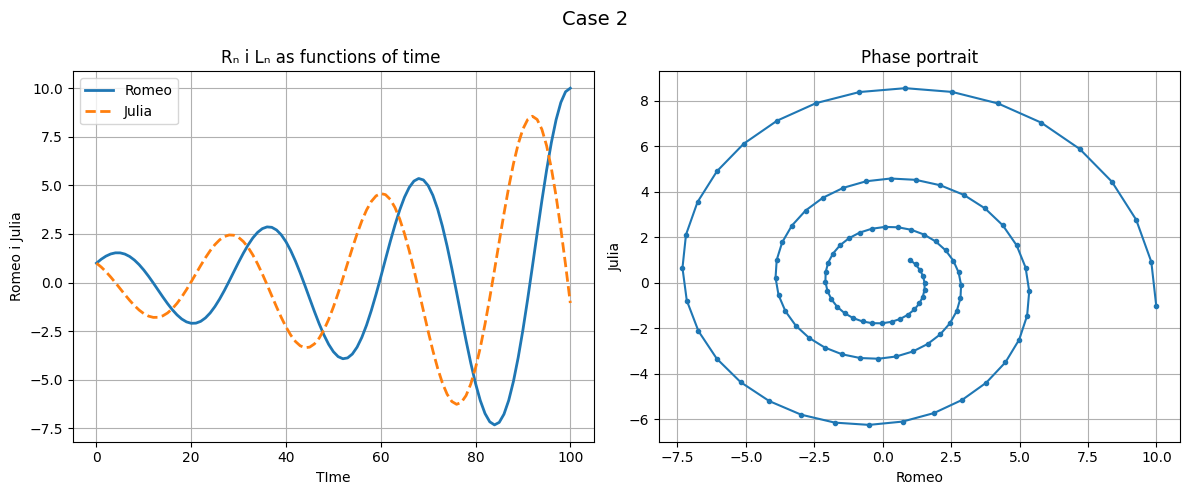

In [5]:
R, L = romeo_julia(R0=1, L0=1, aR=1.0, aL=1.0, pR=0.2, pL=-0.2)
plot_results(R, L, "Case 2")

### Conclusion 
Romeo and Juliet do not exhibit a natural tendency to suppress their emotions, as the parameters aR = aL = 1. Romeo responds positively to Juliet's love, while Juliet reacts in the opposite way: when Romeo loves her, she distances herself, and when he stops reciprocating, her emotions increase. The values ​​of Rn and Ln fluctuate alternately - the love of one leads to the cooling of the other, which in turn triggers the opposite reaction in the subsequent steps. The system does not reach a stable equilibrium point, but moves cyclically around zero. Such a system corresponds to a relationship in which the partners' feelings are constantly changing. Ultimately, the system does not converge to any constant value, but generates persistent "mood swings."

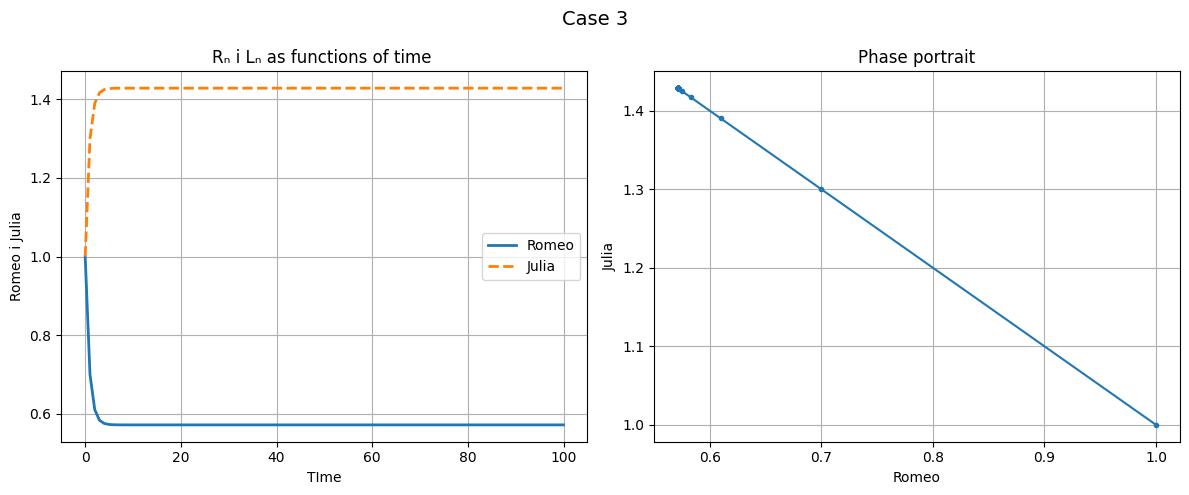

In [6]:
R, L = romeo_julia(R0=1, L0=1, aR=0.5, aL=0.8, pR=0.2, pL=0.5)
plot_results(R, L, "Case 3")

### Conclusion 
In the third case, Romeo and Juliet begin with a moderate level of love (R₀ = L₀ = 1), with their emotional reactions being positive but not too strong. The parameters aR and aL are less than 1, indicating a natural decay of emotions over time, while the pR and pL couplings are positive, allowing their feelings to be mutually reinforced for a time. Juliet reacts more strongly to Romeo's emotions than he does to hers, because pL > pR, leading to a slight dynamic asymmetry. The Rn and Ln graphs show gentle, damped oscillations that gradually fade away. The system is stable, with the amplitude of the oscillations decreasing over time until both reach a state of emotional equilibrium. This describes a relationship that is initially characterized by some emotional fluctuations but gradually calms down and stabilizes.

In [10]:
#case 1
aR = 0.5
aL = 0.7
pR = 0.7
pL = 0.9

A = np.array([
[aR - 1, pR],
[pL, aL - 1]])
print("Matrix A:", A)

detA = np.linalg.det(A)
print("Determinant of matrix A:",detA)

if abs(detA) > 1e-9:
    print("The system has exactly one solution")
else:
    print("The system has infinitely many fixed points")

J = np.array([
[aR, pR],
[pL, aL]])
print("Jacobi matrix:", J)

tr = np.trace(J)
print("Trace of matrix J = ", tr)

detJ = np.linalg.det(J)
print("Determinant of matrix Jacobi: ", detJ)

sum = 1 + detJ
print(f"|tr(j)|={tr} < 1 + det(J) = {sum} < 2 ")
print("Jury's condition is not satisfied -> the point is unstable")

Matrix A: [[-0.5  0.7]
 [ 0.9 -0.3]]
Determinant of matrix A: -0.47999999999999987
The system has exactly one solution
Jacobi matrix: [[0.5 0.7]
 [0.9 0.7]]
Trace of matrix J =  1.2
Determinant of matrix Jacobi:  -0.27999999999999997
|tr(j)|=1.2 < 1 + det(J) = 0.72 < 2 
Jury's condition is not satisfied -> the point is unstable


In [11]:
#case 2
aR = 1.0
aL = 1.0
pR = 0.2
pL = -0.2

A = np.array([
[aR - 1, pR],
[pL, aL - 1]])
print("Matrix A:", A)

detA = np.linalg.det(A)
print("Determinant of matrix A:",detA)

if abs(detA) > 1e-9:
    print("The system has exactly one solution")
else:
    print("The system has infinitely many fixed points")

J = np.array([
[aR, pR],
[pL, aL]])
print(J)

tr = np.trace(J)
print("Trace of matrix J = ", tr)

detJ = np.linalg.det(J)
print("Determinant of Jacobi matrix: ", detJ)

sum = 1 + detJ
print(f"|tr(j)|={tr} < 1 + det(J) = {sum} < 2 ")
print("Jury's condition is not satisfied -> the point is unstable")

Matrix A: [[ 0.   0.2]
 [-0.2  0. ]]
Determinant of matrix A: 0.04000000000000001
The system has exactly one solution
[[ 1.   0.2]
 [-0.2  1. ]]
Trace of matrix J =  2.0
Determinant of Jacobi matrix:  1.04
|tr(j)|=2.0 < 1 + det(J) = 2.04 < 2 
Jury's condition is not satisfied -> the point is unstable


In [13]:
#case 3
aR = 0.5
aL = 0.8
pR = 0.2
pL = 0.5

A = np.array([
[aR - 1, pR],
[pL, aL - 1]])
print("Matrix A:", A)

detA = np.linalg.det(A)
print("Determinant of matrix A:",round(detA,2))

if abs(detA) > 1e-9:
    print("The system has exactly one solution")
else:
    print("The system has infinitely many fixed points")

#task 1.2

#defining symbolic variables
R_star, L_star = sp.symbols('R_star L_star')

#equation (5)
eq = (aR - 1)*R_star + pR*L_star

#solution with respect to L_star
L_star_expr = sp.solve(eq, L_star)[0]
print("Family of fixed points:")
print(f"L* = {sp.simplify(L_star_expr)}")

#assuming initial values, sum of feelings
R0, L0 = 1, 1
total = R0 + L0
eq_sum = sp.Eq(R_star + L_star_expr, total)

R_star_value = sp.solve(eq_sum, R_star)[0]
L_star_value = L_star_expr.subs(R_star, R_star_value)

print(f"R* = {R_star_value:.6f}")
print(f"L* = {L_star_value:.6f}")

Matrix A: [[-0.5  0.2]
 [ 0.5 -0.2]]
Determinant of matrix A: -0.0
The system has infinitely many fixed points
Family of fixed points:
L* = 2.5*R_star
R* = 0.571429
L* = 1.428571


In [14]:
#symbolic variables
aR, aL, pR, pL = sp.symbols('aR aL pR pL')

#Jacobi matrix
J = sp.Matrix([[aR, pR],
[pL, aL]])

#conditions for the invariance of emotions (7)
eq1 = sp.Eq(aR + pL, 1)
eq2 = sp.Eq(aL + pR, 1)

#we determine the eigenvalues ​​symbolically
eigvals = J.eigenvals()
print("Jacobi eigenvalues ​​before substituting condition (7):")
print(eigvals)

#substitute the conditions
conditions = {pL: 1 - aR, pR: 1 - aL}
eigvals_subs = J.subs(conditions).eigenvals()
print("\nJacobi eigenvalues ​​after substitution of conditions (7):")
print(eigvals_subs)

Jacobi eigenvalues ​​before substituting condition (7):
{aL/2 + aR/2 - sqrt(aL**2 - 2*aL*aR + aR**2 + 4*pL*pR)/2: 1, aL/2 + aR/2 + sqrt(aL**2 - 2*aL*aR + aR**2 + 4*pL*pR)/2: 1}

Jacobi eigenvalues ​​after substitution of conditions (7):
{1: 1, aL + aR - 1: 1}
